In [1]:
from __future__ import annotations

import numpy as np
import pandas as pd
import os
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.model_selection import LeaveOneOut
from sklearn.base import clone
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
)
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings('ignore')

METRIC_NAMES = ["Accuracy", "Precision", "Recall", "F1-score", "AUROC", "AUPRC"]
MIMIC_PATH = '../../datasets/MIMIC-IV-CRAB/mimicset0227.csv'

USE_SMOTE = False
SMOTE_RATIO = 0.8
RANDOM_STATE = 42
SAVE_DIR = "results/mimic-crab"
TARGET = "survival"
LOOCV_THRESHOLD = 0.5
os.makedirs(SAVE_DIR, exist_ok=True)

In [ ]:
# -----------------------------
# Models & Pipeline
# -----------------------------
def get_models(scale_pos_weight, use_smote=False):
    if use_smote:
        models = {
        'XGBoost': XGBClassifier(eval_metric='auc', verbosity=0, random_state=42, n_jobs=1),
        'LightGBM': LGBMClassifier(verbosity=-1, random_state=42, n_jobs=1),
        'CatBoost': CatBoostClassifier(verbose=0, allow_writing_files=False, random_state=42, thread_count=1),
        'RandomForest': RandomForestClassifier(random_state=42, n_jobs=1),
        'LogisticRegression': LogisticRegression(random_state=42, max_iter=1000),
        'SVM': SVC(random_state=42, probability=True),
        'KNN': KNeighborsClassifier(n_jobs=1),
    }
    else:
        models={
        'XGBoost': XGBClassifier(scale_pos_weight=scale_pos_weight, use_label_encoder=False, objective='binary:logistic', eval_metric='logloss', verbosity=0, random_state=42, n_jobs=1),
        'LightGBM': LGBMClassifier(class_weight='balanced', verbosity=-1, random_state=42, n_jobs=1),
        'CatBoost': CatBoostClassifier(auto_class_weights='Balanced', verbose=0, loss_function='Logloss', allow_writing_files=False, random_state=42, thread_count=1),
        'RandomForest': RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=1),
        'LogisticRegression': LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000),
        'SVM': SVC(class_weight='balanced',random_state=42, probability=True),
        'KNN': KNeighborsClassifier(weights='distance', n_jobs=1),
    }
    return models


TREE_MODELS = {"XGBoost", "LightGBM", "CatBoost", "RandomForest"}
def is_tree(model_name):
    return model_name in TREE_MODELS

def create_pipeline(model, model_name, use_smote=False, smote_ratio=0.8):
    steps = [("imputer", SimpleImputer(strategy="median"))]
    if not is_tree(model_name):
        steps.append(("scaler", StandardScaler()))
    if use_smote:
        steps.append(("smote", SMOTE(random_state=42, sampling_strategy=smote_ratio, k_neighbors=3)))
    steps.append(("clf", clone(model)))
    return ImbPipeline(steps) if use_smote else Pipeline(steps)

In [3]:
# -----------------------------
# Metrics & Tools
# -----------------------------
def evaluate_model(y_true, y_pred, y_proba):
    return {
        "Accuracy": float(accuracy_score(y_true, y_pred)),
        "Precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "Recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "F1-score": float(f1_score(y_true, y_pred, zero_division=0)),
        "AUROC": float(roc_auc_score(y_true, y_proba)),
        "AUPRC": float(average_precision_score(y_true, y_proba)),
    }

def get_medication_features():
    return ['Aminoglycoside', 'CMS', 'Carbapenem', 'Minocycline', 'Sulbactam', 'Tigecycline', 'Vancomycin']

def expand_featureset(featureset, available_cols, group_defs):
    expanded = []
    for f in featureset:
        if f in group_defs:
            expanded.extend([c for c in group_defs[f] if c in available_cols])
        elif f in available_cols:
            expanded.append(f)
    return list(dict.fromkeys(expanded))

def get_featureset_subset(X, featureset, group_defs, verbose=True):
    medication_candidates = get_medication_features()
    medication_cols = [c for c in medication_candidates if c in X.columns]
    featureset_expanded = expand_featureset(featureset, X.columns, group_defs)
    cols_best = medication_cols + [c for c in featureset_expanded if c in X.columns]
    cols_best = list(dict.fromkeys(cols_best))
    X_sub = X[cols_best].copy()
    if verbose:
        print(f"Feature set ({len(cols_best)} cols): {cols_best}\n")
    return X_sub, cols_best

def evaluate_loocv(
    X_sub,
    y_full,
    models,
    use_smote=False,
    smote_ratio=0.8,
    verbose=True,
    meta_df=None,
    candidate=None,
    threshold=0.5,
):
    loo = LeaveOneOut()
    results = {name: {'y_true': [], 'y_proba': []} for name in models}
    detail_rows = []
    record_detail = meta_df is not None and candidate is not None
    if record_detail:
        meta_df = meta_df.reindex(X_sub.index)

    for train_idx, val_idx in loo.split(X_sub):
        X_tr = X_sub.iloc[train_idx]
        X_val = X_sub.iloc[val_idx]
        y_tr = y_full.iloc[train_idx]
        y_val = y_full.iloc[val_idx]
        pos = int(val_idx[0])
        sid = hid = None
        if record_detail:
            sid = meta_df.iloc[pos]["subject_id"]
            hid = meta_df.iloc[pos]["hadm_id"]

        for model_name, model in models.items():
            pipe = create_pipeline(model, model_name, use_smote=use_smote, smote_ratio=smote_ratio)
            pipe.fit(X_tr, y_tr)
            proba = pipe.predict_proba(X_val)[:, 1]
            p0 = float(proba[0])
            results[model_name]['y_true'].append(y_val.values[0])
            results[model_name]['y_proba'].append(p0)
            if record_detail:
                yt = int(y_val.values[0])
                detail_rows.append(
                    {
                        "subject_id": sid,
                        "hadm_id": hid,
                        "y_true": yt,
                        "y_proba": p0,
                        "candidate": candidate,
                        "model": model_name,
                        "threshold": threshold,
                        "y_pred": int(p0 >= threshold),
                    }
                )

    loocv_metrics = {}
    for model_name in models:
        y_true = np.array(results[model_name]['y_true'])
        y_proba = np.array(results[model_name]['y_proba'])
        y_pred = (y_proba >= threshold).astype(int)
        loocv_metrics[model_name] = evaluate_model(y_true, y_pred, y_proba)
    loocv_df = pd.DataFrame(loocv_metrics).T
    if verbose:
        print("LOOCV (full data) results:")
        print(loocv_df.to_string())

    for k in results:
        results[k]['y_true'] = np.array(results[k]['y_true'])
        results[k]['y_proba'] = np.array(results[k]['y_proba'])
    detail_df = pd.DataFrame(detail_rows) if record_detail else None
    return loocv_df, results, detail_df

In [4]:
full_df = pd.read_csv(MIMIC_PATH, encoding='utf-8')
target = TARGET
full_df = full_df[full_df[target].notna()].copy()
full_df[target] = full_df[target].astype(int)
full_df = full_df[full_df['AnyMedicine'] == 1].copy()


comorb_map = {
    'comorb_diabetes': 'Diabetes Mellitus', 'comorb_hypertension': 'Hypertension',
    'comorb_heart_disease': 'Heart Disease', 'comorb_cerebrovascular': 'Stroke',
    'comorb_malignancy': 'Malignant Tumor', 'comorb_ckd': 'Chronic Kidney Disease',
    'comorb_liver': 'Chronic Liver Disease', 'comorb_copd': 'COPD',
}
for src, dst in comorb_map.items():
    if src in full_df.columns:
        full_df[dst] = full_df[src].fillna(0)
if 'Comorb_other' not in full_df.columns:
    full_df['Comorb_other'] = 0

immuno_map = {
    'immuno_drug_use': 'Use immunosuppressive agents', 'immuno_neutropenia': 'Neutrophil Reduction',
    'immuno_hiv': 'HIV/AIDS', 'immuno_transplant': 'Post-Transplant Status',
    'immuno_chemo_radio': 'Chemotherapy/Radiation', 'immuno_other': 'immuno_Other',
}
for src, dst in immuno_map.items():
    if src in full_df.columns:
        full_df[dst] = full_df[src].fillna(0)

MEDICATION_COLS_MIMIC = ['Aminoglycoside', 'CMS', 'Carbapenem', 'Minocycline', 'Sulbactam', 'Tigecycline', 'Vancomycin']
for c in MEDICATION_COLS_MIMIC:
    if c in full_df.columns:
        full_df[c] = pd.to_numeric(full_df[c], errors='coerce')
        full_df[c] = full_df[c].fillna(0)

full_df['Gender'] = (full_df['Gender'].astype(str).str.upper() == 'M').astype(int)

if 'Cr_baseline' in full_df.columns and 'Age' in full_df.columns:
    cr = pd.to_numeric(full_df['Cr_baseline'], errors='coerce')
    age = pd.to_numeric(full_df['Age'], errors='coerce')
    is_female = (full_df['Gender'] == 0) if 'Gender' in full_df.columns else pd.Series(False, index=full_df.index)
    kappa = np.where(is_female, 0.7, 0.9)
    alpha = np.where(is_female, -0.241, -0.302)
    ratio = cr / kappa
    ratio = np.clip(ratio, 1e-12, None)
    term1 = np.minimum(ratio, 1.0) ** alpha
    term2 = np.maximum(ratio, 1.0) ** (-1.200)
    egfr = 142.0 * term1 * term2 * (0.9938 ** age) * np.where(is_female, 1.012, 1.0)
    egfr = np.clip(egfr, 1, 200)
    full_df['eGFR1'] = np.where((cr > 0) & cr.notna() & age.notna(), egfr, np.nan)
elif 'eGFR1' not in full_df.columns:
    full_df['eGFR1'] = np.nan


COMBORB_COLS = list(comorb_map.values()) + ['Comorb_other']
IMMUNO_COLS = list(immuno_map.values())
group_defs = {'Comorbidity': COMBORB_COLS, 'Immunosuppression': IMMUNO_COLS}

MEDICATION_COLS = get_medication_features()
SINGLE_FEATURES = ['PLT', 'eGFR1', 'PCT1', 'Age', 'ALB', 'N_percent', 'Oxygen_concentration', 'Cr_baseline', 'CRP1']
ALL_FEATURE_COLS = MEDICATION_COLS + COMBORB_COLS + IMMUNO_COLS + SINGLE_FEATURES
feature_cols = [c for c in ALL_FEATURE_COLS if c in full_df.columns]

print(full_df[target].value_counts())
print(f"Full shape: {full_df.shape}")

survival
1    33
0     9
Name: count, dtype: int64
Full shape: (42, 74)


In [5]:
X_full = full_df[feature_cols].copy()
y_full = full_df[target]

missing_pct = X_full.isna().mean() * 100
missing_df = pd.DataFrame({
    'feature': missing_pct.index,
    'missing_pct (%)': missing_pct.values.round(2),
    'missing_count': X_full.isna().sum().values
}).sort_values('missing_pct (%)', ascending=False)
print(missing_df.to_string(index=False))

scale_pos_weight = (y_full == 0).sum() / max((y_full == 1).sum(), 1)
models = get_models(scale_pos_weight, use_smote=USE_SMOTE)

                     feature  missing_pct (%)  missing_count
                        CRP1            83.33             35
                         ALB            40.48             17
                   N_percent            35.71             15
        Oxygen_concentration            30.95             13
                       eGFR1             2.38              1
              Aminoglycoside             0.00              0
                  Vancomycin             0.00              0
           Diabetes Mellitus             0.00              0
                Hypertension             0.00              0
                         CMS             0.00              0
                  Carbapenem             0.00              0
                 Minocycline             0.00              0
                   Sulbactam             0.00              0
                 Tigecycline             0.00              0
       Chronic Liver Disease             0.00              0
      Chronic Kidney Dis

In [6]:
CANDIDATES = {
    'feature-setA': ['PLT', 'eGFR1', 'Comorbidity', 'PCT1', 'Age', 'ALB', 'N_percent', 'Oxygen_concentration', 'Cr_baseline'],
    'feature-setB': ['Comorbidity', 'Age', 'N_percent', 'CRP1', 'Oxygen_concentration', 'Immunosuppression', 'Cr_baseline'],
}

LOOCV_DETAIL_COLS = [
    "subject_id", "hadm_id", "y_true", "y_proba", "candidate", "model", "threshold", "y_pred",
]

all_loocv = []
loocv_predictions = {}
all_detail_dfs = []
meta_ids = full_df.loc[X_full.index, ["subject_id", "hadm_id"]]

for name, featureset in CANDIDATES.items():
    print(f"\n{'='*60}\n>>> {name}: {featureset}\n{'='*60}")
    X_sub, cols_best = get_featureset_subset(
        X_full, featureset=featureset, group_defs=group_defs, verbose=True
    )
    loocv_metrics_df, results, detail_df = evaluate_loocv(
        X_sub,
        y_full,
        models,
        use_smote=USE_SMOTE,
        smote_ratio=SMOTE_RATIO,
        verbose=True,
        meta_df=meta_ids,
        candidate=name,
        threshold=LOOCV_THRESHOLD,
    )
    all_loocv.append(loocv_metrics_df.assign(candidate=name))
    loocv_predictions[name] = results
    if detail_df is not None:
        all_detail_dfs.append(detail_df[LOOCV_DETAIL_COLS])

loocv_summary = pd.concat(all_loocv, ignore_index=False).set_index('candidate', append=True)
loocv_summary.to_csv(f"{SAVE_DIR}/survival_loocv_median.csv")

if all_detail_dfs:
    loocv_detail_path = f"{SAVE_DIR}/survival_loocv_pred_for_confusion_matrix.csv"
    pd.concat(all_detail_dfs, ignore_index=True).to_csv(loocv_detail_path, index=False)


>>> feature-setA: ['PLT', 'eGFR1', 'Comorbidity', 'PCT1', 'Age', 'ALB', 'N_percent', 'Oxygen_concentration', 'Cr_baseline']
Feature set (23 cols): ['Aminoglycoside', 'CMS', 'Carbapenem', 'Minocycline', 'Sulbactam', 'Tigecycline', 'Vancomycin', 'PLT', 'eGFR1', 'Diabetes Mellitus', 'Hypertension', 'Heart Disease', 'Stroke', 'Malignant Tumor', 'Chronic Kidney Disease', 'Chronic Liver Disease', 'COPD', 'Comorb_other', 'Age', 'ALB', 'N_percent', 'Oxygen_concentration', 'Cr_baseline']

LOOCV (full data) results:
                    Accuracy  Precision    Recall  F1-score     AUROC     AUPRC
XGBoost             0.833333   0.906250  0.878788  0.892308  0.767677  0.911202
LightGBM            0.809524   0.931034  0.818182  0.870968  0.784512  0.916720
CatBoost            0.761905   0.828571  0.878788  0.852941  0.656566  0.837509
RandomForest        0.809524   0.804878  1.000000  0.891892  0.764310  0.915273
LogisticRegression  0.785714   0.928571  0.787879  0.852459  0.865320  0.958226
SVM    

In [7]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def plot_confusion_matrix(y_true, y_pred, labels=None, title='Confusion Matrix', ax=None):
    cm = confusion_matrix(y_true, y_pred)
    if ax is None:
        fig, ax = plt.subplots(figsize=(4, 3))
    if labels is None:
        labels = ['Neg', 'Pos']  # 0, 1
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=labels, yticklabels=labels,
                ax=ax, cmap='Blues', cbar=False)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.set_title(title)
    plt.tight_layout()
    return ax

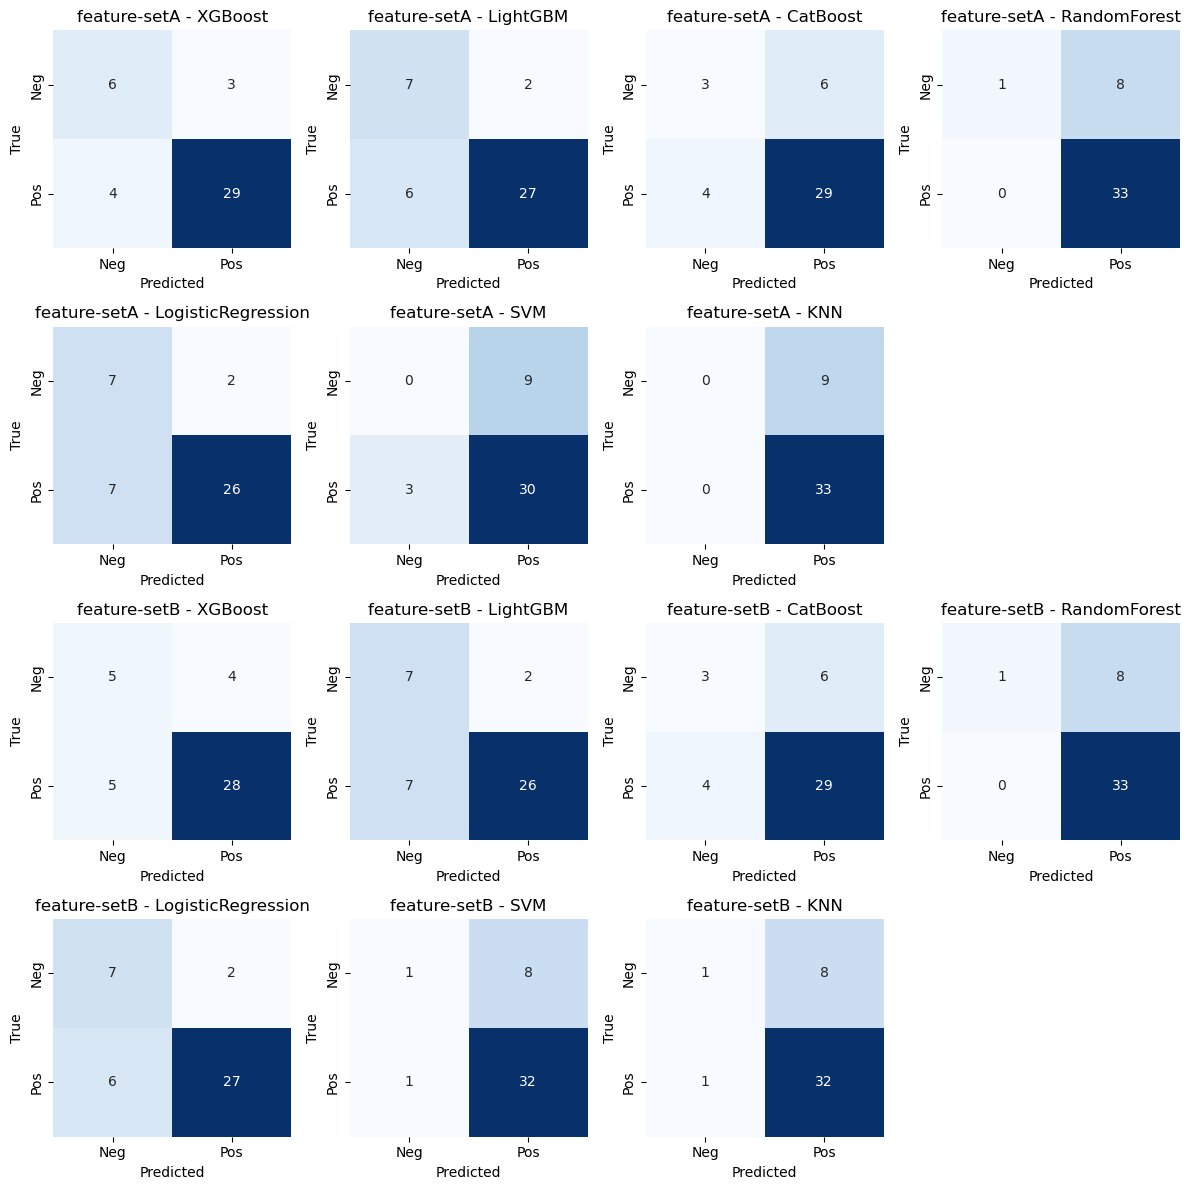


>>> feature-setA: true label + LOOCV pred (pred = proba>=0.5, use_smote=False)
    actual  XGBoost_proba  XGBoost_pred  LightGBM_proba  LightGBM_pred  CatBoost_proba  CatBoost_pred  RandomForest_proba  RandomForest_pred  LogisticRegression_proba  LogisticRegression_pred  SVM_proba  SVM_pred  KNN_proba  KNN_pred
0        1         0.9769             1          0.9069              1          0.6979              1                0.78                  1                    0.7093                        1     0.7274         1     0.5986         1
1        0         0.1376             0          0.2257              0          0.2055              0                0.43                  0                    0.1362                        0     0.5513         1     0.7832         1
2        1         0.6279             1          0.7998              1          0.5632              1                0.74                  1                    0.4175                        0     0.4534         0     0

In [8]:
n_candidates = len(CANDIDATES)
n_models = len(models)
n_cols = 4
n_rows = n_candidates * 2

fig, axes = plt.subplots(n_rows, n_cols, figsize=(3 * n_cols, 3 * n_rows))
axes = np.atleast_2d(axes)

proba_tables = {}
for i_cand, name in enumerate(CANDIDATES):
    results = loocv_predictions[name]
    data = {"actual": results[list(models.keys())[0]]["y_true"]}
    for i_model, model_name in enumerate(models):
        row = i_cand * 2 + i_model // n_cols
        col = i_model % n_cols
        ax = axes[row, col]
        y_true = results[model_name]["y_true"]
        y_proba = results[model_name]["y_proba"]
        pred = (y_proba >= LOOCV_THRESHOLD).astype(int)
        data[f"{model_name}_proba"] = y_proba
        data[f"{model_name}_pred"] = pred
        plot_confusion_matrix(y_true, pred, title=f"{name} - {model_name}", ax=ax)
    proba_tables[name] = pd.DataFrame(data, index=np.arange(len(data["actual"])))
    for slot in range(n_models, 2 * n_cols):
        r, c = i_cand * 2 + slot // n_cols, slot % n_cols
        axes[r, c].set_visible(False)

plt.tight_layout()
plt.show()

for name in CANDIDATES:
    print(f"\n{'='*60}\n>>> {name}: true label + LOOCV pred (pred = proba>={LOOCV_THRESHOLD}, use_smote={USE_SMOTE})\n{'='*60}")
    print(proba_tables[name].round(4).to_string())